In [3]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.impute import SimpleImputer
from google.colab import drive

# 1. CARGA DE DATOS

ruta_archivo = "/dataR2.csv"
df = pd.read_csv(ruta_archivo)

print("Dataset 'Breast Cancer Coimbra Dataset' cargado correctamente.")
print("Primeras 5 filas del dataset:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset 'Breast Cancer Coimbra Dataset' cargado correctamente.
Primeras 5 filas del dataset:


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [4]:
print("Filas y columnas:", df.shape)
print("\nColumnas:\n", df.columns)
df.info()
df.describe(include="all")


Filas y columnas: (116, 10)

Columnas:
 Index(['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin',
       'Resistin', 'MCP.1', 'Classification'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [5]:
for col in df.columns:
    print("\n>>>", col)
    print(df[col].value_counts())



>>> Age
Age
45    7
66    5
49    5
69    5
75    4
76    4
48    4
51    4
44    4
34    3
86    3
72    3
54    3
71    3
43    3
68    3
46    3
65    3
82    2
40    2
62    2
42    2
59    2
85    2
77    2
29    2
38    2
73    2
64    2
60    2
36    2
35    2
83    1
89    1
24    1
61    1
47    1
25    1
28    1
32    1
67    1
50    1
53    1
55    1
78    1
81    1
41    1
58    1
52    1
74    1
57    1
Name: count, dtype: int64

>>> BMI
BMI
21.367521    2
31.975015    2
27.688778    2
32.461911    2
26.562500    2
            ..
26.850000    1
26.840000    1
32.050000    1
25.590000    1
27.180000    1
Name: count, Length: 110, dtype: int64

>>> Glucose
Glucose
92     9
90     6
85     4
77     4
82     4
97     4
86     4
87     4
83     4
101    4
103    4
84     3
88     3
93     3
89     3
94     3
102    3
95     3
98     3
100    3
134    2
99     2
78     2
70     2
105    2
106    2
112    2
131    2
118    1
91     1
75     1
76     1
80     1
79     1
116    1


In [6]:
# REMOVED: Limpieza de valores raros no es necesaria para este dataset.

In [7]:
# REMOVED: Filtros de columnas específicos del dataset anterior.

In [8]:
# REMOVED: Mapeos de columnas específicos del dataset anterior.

In [9]:
# REMOVED: Conversión general a numérico no es necesaria para las características ya numéricas.

In [10]:
# 4. SELECCIÓN DE VARIABLES Y TRANSFORMACIÓN DE LA VARIABLE OBJETIVO

feature_columns = [
    'Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1'
]
X = df[feature_columns]
y = df["Classification"]

# Transformación de la Variable Objetivo: 2 (Cáncer) -> 1, 1 (Sano) -> 0
y = y.map({1: 0, 2: 1})

print("Nuevas dimensiones de X:", X.shape)
print("Conteo de la variable objetivo (y) después del mapeo:")
display(y.value_counts())

Nuevas dimensiones de X: (116, 9)
Conteo de la variable objetivo (y) después del mapeo:


,count
Classification,
1,64
0,52


In [11]:
# 5. PARTICIÓN DE DATOS (TRAIN-TEST SPLIT)

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones del conjunto de entrenamiento X_train:", X_train.shape)
print("Dimensiones del conjunto de prueba X_test:", X_test.shape)
print("Dimensiones del conjunto de entrenamiento y_train:", y_train.shape)
print("Dimensiones del conjunto de prueba y_test:", y_test.shape)

Dimensiones del conjunto de entrenamiento X_train: (92, 9)
Dimensiones del conjunto de prueba X_test: (24, 9)
Dimensiones del conjunto de entrenamiento y_train: (92,)
Dimensiones del conjunto de prueba y_test: (24,)


In [12]:
from sklearn.preprocessing import StandardScaler

# 6. IMPUTACIÓN DE VALORES NULOS (si los hubiera) Y ESCALADO

# Imputación de valores nulos
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Escalado de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Valores NaN manejados y características escaladas en X_train y X_test.")
print("Primeras 5 filas de X_train escalado:")
display(X_train.head())

Valores NaN manejados y características escaladas en X_train y X_test.
Primeras 5 filas de X_train escalado:


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
85,0.416863,0.363373,-0.604432,0.564394,0.164223,0.007994,-0.429698,0.420985,3.367421
2,1.476983,-0.914196,-0.331622,-0.614514,-0.532530,-0.439000,1.653546,-0.420331,0.037256
82,-0.643257,0.909282,0.032124,2.193565,1.492845,1.027307,1.535003,-0.347639,0.571066
101,0.479223,-0.242819,-0.422559,-0.379220,-0.389721,-0.596952,-0.271955,0.045673,-0.793173
4,1.726423,-1.307426,-0.286154,-0.724728,-0.601560,-1.024753,-0.768485,-0.313024,0.675553


In [13]:
from sklearn.model_selection import StratifiedKFold

# 7. OPTIMIZACIÓN DE HIPERPARÁMETROS CON STRATIFIED K-FOLD

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 8. HIPERPARÁMETROS PARA EVITAR SOBREENTRENAMIENTO

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 12, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=skf.split(X_train, y_train),
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

# 9. AJUSTAMOS EL MODELO

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_
print("Mejores hiperparámetros encontrados:", random_search.best_params_)

Mejores hiperparámetros encontrados: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced'}


In [14]:
# 10. VALIDACIÓN CRUZADA Y CURVAS ROC PARA EL MEJOR MODELO
roc_auc_scores = []
tpr_list = []
fpr_list = []
mean_fpr = np.linspace(0, 1, 100)

print("Iniciando la validación cruzada estratificada (StratifiedKFold) y cálculo del ROC AUC")

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Entrenar el mejor modelo en cada fold
    best_rf.fit(X_train_fold, y_train_fold)

    y_pred_proba = best_rf.predict_proba(X_val_fold)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_val_fold, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)

    interpolated_tpr = np.interp(mean_fpr, fpr, tpr)
    interpolated_tpr[0] = 0.0
    tpr_list.append(interpolated_tpr)

    print(f"Fold {fold+1} - ROC AUC: {roc_auc:.4f}")

Iniciando la validación cruzada estratificada (StratifiedKFold) y cálculo del ROC AUC
Fold 1 - ROC AUC: 0.8750
Fold 2 - ROC AUC: 0.8333
Fold 3 - ROC AUC: 0.8625
Fold 4 - ROC AUC: 0.6500
Fold 5 - ROC AUC: 0.5875


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# 11. EVALUACIÓN FINAL SOBRE DATOS DE PRUEBA (X_test)
y_pred_test = best_rf.predict(X_test)

# Obtener la Matriz de Confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
especificidad = tn / (tn + fp) # Capacidad de identificar correctamente a los sanos (clase 0)

print("--- EVALUACIÓN FINAL SOBRE DATOS DE PRUEBA ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Clase 1 - Cáncer): {precision:.4f}")
print(f"Recall (Clase 1 - Cáncer): {recall:.4f}")
print(f"F1-Score (Clase 1 - Cáncer): {f1:.4f}")
print(f"Especificidad (Clase 0 - Sano): {especificidad:.4f}")
print(f"Interpretación: El modelo identifica correctamente al {especificidad*100:.2f}% de las personas que no tienen cáncer de mama.")
print("\nReporte detallado:")
print(classification_report(y_test, y_pred_test))

--- EVALUACIÓN FINAL SOBRE DATOS DE PRUEBA ---
Accuracy: 0.6667
Precision (Clase 1 - Cáncer): 0.7778
Recall (Clase 1 - Cáncer): 0.5385
F1-Score (Clase 1 - Cáncer): 0.6364
Especificidad (Clase 0 - Sano): 0.8182
Interpretación: El modelo identifica correctamente al 81.82% de las personas que no tienen cáncer de mama.

Reporte detallado:
              precision    recall  f1-score   support

           0       0.60      0.82      0.69        11
           1       0.78      0.54      0.64        13

    accuracy                           0.67        24
   macro avg       0.69      0.68      0.66        24
weighted avg       0.70      0.67      0.66        24



In [16]:
# 12. AJUSTE DE UMBRAL (EJEMPLO)

# En lugar de usar .predict(), usamos las probabilidades
y_probs = best_rf.predict_proba(X_test)[:, 1]

# Probamos con un umbral más alto (ejemplo: 0.6)
nuevo_umbral = 0.6
y_pred_ajustado = (y_probs >= nuevo_umbral).astype(int)

# Calculamos la nueva matriz y métricas
tn_adj, fp_adj, fn_adj, tp_adj = confusion_matrix(y_test, y_pred_ajustado).ravel()
especificidad_adj = tn_adj / (tn_adj + fp_adj)
precision_adj = tp_adj / (tp_adj + fp_adj) if (tp_adj + fp_adj) > 0 else 0
recall_adj = tp_adj / (tp_adj + fn_adj) if (tp_adj + fn_adj) > 0 else 0
f1_adj = 2 * (precision_adj * recall_adj) / (precision_adj + recall_adj) if (precision_adj + recall_adj) > 0 else 0

print(f"--- EVALUACIÓN CON UMBRAL AJUSTADO ({nuevo_umbral}) ---")
print(f"Nueva Especificidad (Clase 0 - Sano): {especificidad_adj:.4f}")
print(f"Nueva Precisión (Clase 1 - Cáncer): {precision_adj:.4f}")
print(f"Nuevo Recall (Clase 1 - Cáncer): {recall_adj:.4f}")
print(f"Nuevo F1-Score (Clase 1 - Cáncer): {f1_adj:.4f}")
print("\nNuevo Reporte:")
print(classification_report(y_test, y_pred_ajustado))

--- EVALUACIÓN CON UMBRAL AJUSTADO (0.6) ---
Nueva Especificidad (Clase 0 - Sano): 0.8182
Nueva Precisión (Clase 1 - Cáncer): 0.7500
Nuevo Recall (Clase 1 - Cáncer): 0.4615
Nuevo F1-Score (Clase 1 - Cáncer): 0.5714

Nuevo Reporte:
              precision    recall  f1-score   support

           0       0.56      0.82      0.67        11
           1       0.75      0.46      0.57        13

    accuracy                           0.62        24
   macro avg       0.66      0.64      0.62        24
weighted avg       0.66      0.62      0.62        24



/tmp/ipykernel_7570/658691539.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


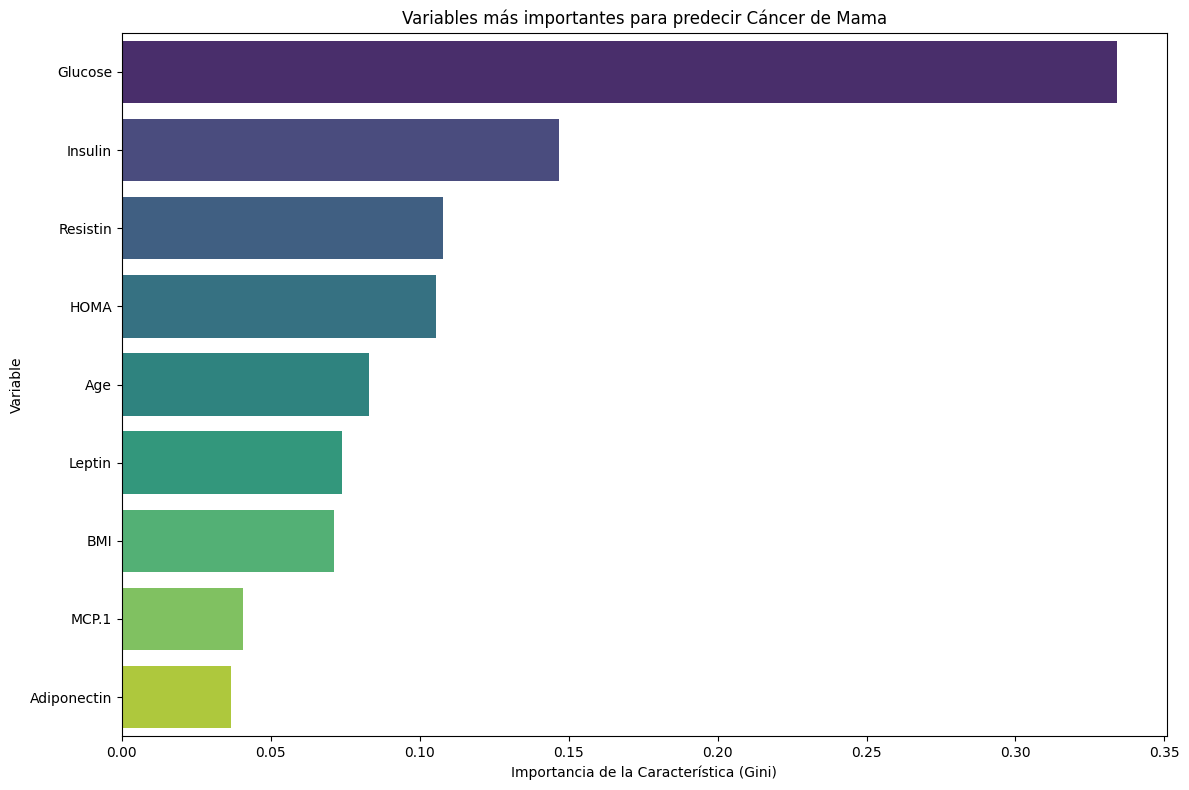

Top 9 features by importance:
      Variable  Importancia
2      Glucose     0.334026
3      Insulin     0.146898
7     Resistin     0.107697
4         HOMA     0.105606
0          Age     0.083183
5       Leptin     0.074036
1          BMI     0.071161
8        MCP.1     0.040814
6  Adiponectin     0.036578


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 13. Extraer las importancias de las variables
importancias = best_rf.feature_importances_
columnas = X_train.columns

# Crear un DataFrame para visualizar mejor
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Variables más importantes para predecir Cáncer de Mama')
plt.xlabel('Importancia de la Característica (Gini)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print("Top 9 features by importance:")
print(df_importancia.head(9))


ROC AUC promedio de la validación cruzada: 0.7610 (+/- 0.1191)


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7570/3395390759.py:19: SyntaxWarning: invalid escape sequence '\p'
  label=f'ROC promedio (AUC = {mean_roc_auc:.2f} $\pm$ {std_auc:.2f})',


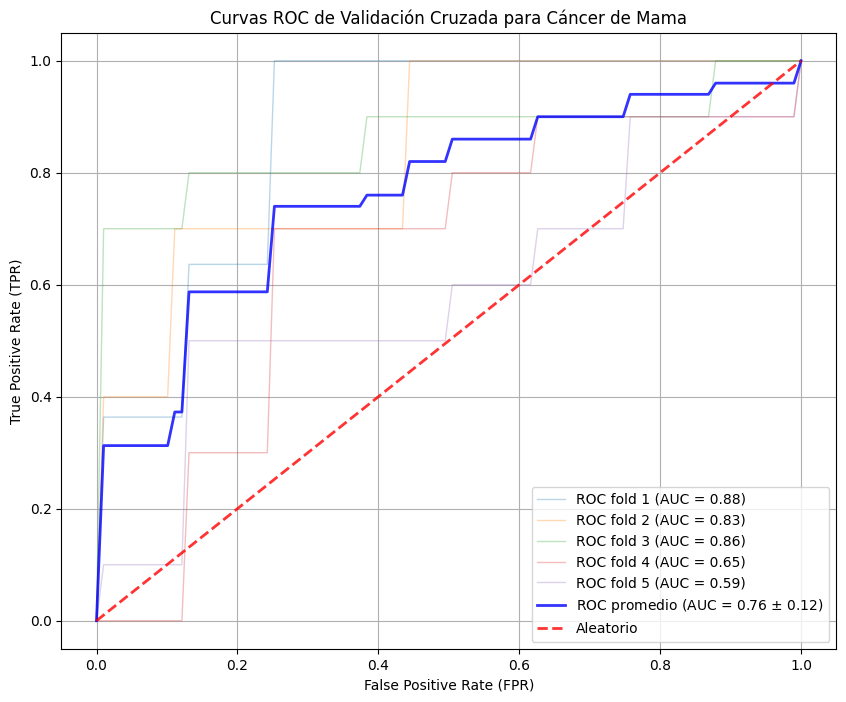


Interpretación de resultados:
El valor promedio de ROC AUC obtenido de la validación cruzada es de 0.7610.
Un valor cercano a 1.0 indica un excelente rendimiento del modelo en la discriminación entre pacientes con y sin cáncer de mama, mientras que un valor cercano a 0.5 indica un rendimiento aleatorio.
La visualización de las curvas ROC muestra la capacidad del modelo para balancear la tasa de verdaderos positivos y falsos positivos a través de diferentes umbrales.
Las curvas individuales para cada fold y la curva promedio proporcionan una visión robusta del rendimiento general del modelo y su variabilidad.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el ROC AUC promedio y la curva ROC promedio
mean_tpr = np.mean(tpr_list, axis=0)
mean_tpr[-1] = 1.0 # Asegurar que la curva termina en (1,1)
mean_roc_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(roc_auc_scores)

print(f"\nROC AUC promedio de la validación cruzada: {mean_roc_auc:.4f} (+/- {std_auc:.4f})")

# Graficar las curvas ROC
plt.figure(figsize=(10, 8))
for i, tpr in enumerate(tpr_list):
    plt.plot(mean_fpr, tpr, lw=1, alpha=0.3,
             label=f'ROC fold {i+1} (AUC = {roc_auc_scores[i]:.2f})')

plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'ROC promedio (AUC = {mean_roc_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2, alpha=0.8)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8, label='Aleatorio')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curvas ROC de Validación Cruzada para Cáncer de Mama')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\nInterpretación de resultados:")
print(f"El valor promedio de ROC AUC obtenido de la validación cruzada es de {mean_roc_auc:.4f}.")
print("Un valor cercano a 1.0 indica un excelente rendimiento del modelo en la discriminación entre pacientes con y sin cáncer de mama, mientras que un valor cercano a 0.5 indica un rendimiento aleatorio.")
print("La visualización de las curvas ROC muestra la capacidad del modelo para balancear la tasa de verdaderos positivos y falsos positivos a través de diferentes umbrales.")
print("Las curvas individuales para cada fold y la curva promedio proporcionan una visión robusta del rendimiento general del modelo y su variabilidad.")